# Fourier Transforms with Potential Fields

**Geophysics IIIA — Practical Notebook**  
D. Hasterok

---

In this practical you will explore how Fourier transforms are applied to
gravity and magnetic data, using real datasets from South Australia.

You will:
- interactively extract profiles
- apply upward and downward continuation
- separate regional and residual fields
- examine the role of sediment thickness
- assess the limitations and non-uniqueness of spectral methods


In [3]:
%matplotlib widget

from pathlib import Path
import sys

_ROOT    = Path.cwd().parent.parent   # src/assignments/ -> project root
DATAPATH = _ROOT / "data"

if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))

import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show
from rasterio.crs import CRS
from scipy.interpolate import RegularGridInterpolator
import ipywidgets as widgets
from IPython.display import display
import xarray as xr

from src.common.plotting.hillshade import hillshade

cmap = "plasma"


## 1. Load Gravity, Magnetic, and Sediment Thickness Data


In [4]:
# Spatial subset bounds
#LON_MAX =  135.0   # degrees E
#LAT_MIN =  -35.0   # degrees N
LON_MAX =  142.0   # degrees E
LAT_MIN =  -40.0   # degrees N

# Gravity
with xr.open_dataset(DATAPATH / "sa_grav_tif_gda2020/SA_GRAV_BA_2007_reconstructed.nc") as src:
    grav = src.gravity.sel(x=slice(None, LON_MAX), y=slice(None, LAT_MIN))
    grav_crs = CRS.from_wkt(grav.coords["crs"].attrs["spatial_ref"])

# Reference grid from gravity
x = grav.x.values
y = grav.y.values

ny, nx = grav.shape
dx = x[1] - x[0]
dy = y[0] - y[1]    # positive northwards

# Magnetics (increasing y in file — flip to match gravity's N-at-row-0 convention)
with xr.open_dataset(DATAPATH / "SA_TMI_GDA2020/SA_WDMAM_adjusted_UTM.nc") as src:
    mag = src.magnetic_anomaly.sel(x=slice(None, LON_MAX), y=slice(LAT_MIN, None))
#mag = mag.isel(y=slice(None, None, -1))

# Topography
with xr.open_dataset(DATAPATH / "topography/SA_DEM_GDA2020.nc") as src:
    elev = src.elevation.sel(x=slice(None, LON_MAX), y=slice(None, LAT_MIN))

# Sediment thickness
with xr.open_dataset(DATAPATH / "OZSEEBASE_sedthick/SA_OZSEEBASE_SED.nc") as src:
    sed = src.sediment_thickness.sel(x=slice(None, LON_MAX), y=slice(None, LAT_MIN))
    sed_crs = CRS.from_wkt(sed.coords["crs"].attrs["spatial_ref"])

# Resample topography onto gravity grid
#topo = elev.interp(x=xr.DataArray(x, dims="x"), y=xr.DataArray(y, dims="y"),
#                   method="linear").values

print(f"Gravity grid : {grav.shape}  x {x.min():.2f}\u2013{x.max():.2f}  y {y.min():.2f}\u2013{y.max():.2f}")
print(f"Magnetics    : {mag.shape}  x {mag.x.values.min():.2f}\u2013{mag.x.values.max():.2f}  y {mag.y.values.min():.2f}\u2013{mag.y.values.max():.2f}")
print(f"Sediment     : {sed.shape}  x {x.min():.2f}\u2013{x.max():.2f}  y {y.min():.2f}\u2013{y.max():.2f}")
print(f"Topography   : {elev.shape}  x {elev.x.values.min():.2f}\u2013{elev.x.values.max():.2f}  y {elev.y.values.min():.2f}\u2013{elev.y.values.max():.2f}")

Gravity grid : (13347, 14173)  x 128.11–141.89  y -38.82–-25.85
Magnetics    : (16684, 17719)  x 128.11–141.89  y -38.82–-25.85
Sediment     : (16352, 15432)  x 128.11–141.89  y -38.82–-25.85
Topography   : (16684, 17719)  x 128.11–141.89  y -38.82–-25.85


### Preparing the data
There are some issues with the original data files that makes them difficult to use directly for Fourier analysis.  One of the limitations of Fourier Transforms is the requirement that data are equally spaced and for 2D, the data need to be in a rectangular grid.  There also cannot be any missing or spurious data values so they would need to be cleaned first.  Thankfully the grids we are using do not have spurious points.

#### Gravity and Magnetics
The gravity and magnetic data grids both contain an irregular area of missing values.  To satisfy Fourier transform assumptions, we restrict analysis to a rectangular region encompassing all observed data.  Gravity data are supplemented by estimating the gravity from an RGB GeoTIFF that is not clipped.  The overlapping region is calibrated to the observed gravity and then that calibration is used to infill the missing data.  The magnetic data are not accompanied with an unclipped grid and so a different method was used to fill the data.  In this case there exists a long‑wavelength global model that was used to infill the values.

In both cases it is advised to avoid using the oceanic data when making interpretations.

#### Sediment Thickness
This dataset was originally distributed with an ESRI Shapefile and RGB GeoTIFF.  We reconstruct the quantitative values and store them in NetCDF so that the data are explicit, reproducible, and inspectable.

In [5]:
hs = hillshade(np.where(np.isnan(elev.values), 0.0, elev.values),
               dx_m=dx * 3e2,
               dy_m=dy * 3e2)

(array([6.1200000e+03, 4.8450300e+05, 2.6098672e+07, 8.8103280e+06,
        3.6271370e+06, 2.4777120e+06, 1.7254600e+06, 1.4469390e+06,
        1.1689330e+06, 1.0418230e+06, 8.9379000e+05, 7.4363200e+05,
        6.6056100e+05, 6.9908500e+05, 6.3151400e+05, 6.1834400e+05,
        6.8554600e+05, 6.6121200e+05, 6.2112200e+05, 6.8700800e+05,
        7.2182600e+05, 7.5316900e+05, 7.6606000e+05, 7.5110900e+05,
        7.9203200e+05, 8.1238200e+05, 8.4944300e+05, 9.5969700e+05,
        1.0193330e+06, 1.1826050e+06, 1.3948420e+06, 1.6989320e+06,
        1.8151730e+06, 1.4953110e+06, 1.1888860e+06, 9.0941500e+05,
        7.6557700e+05, 9.5567300e+05, 7.6874400e+05, 1.2912082e+07,
        7.3852367e+07, 8.3867917e+07, 2.5556909e+07, 1.5136450e+07,
        8.3436910e+06, 2.2346250e+06, 2.3863900e+05, 7.4774000e+04,
        1.6375000e+04, 3.1700000e+02]),
 array([-5949.91699219, -5803.20117188, -5656.48486328, -5509.76904297,
        -5363.05322266, -5216.33691406, -5069.62109375, -4922.90527344,


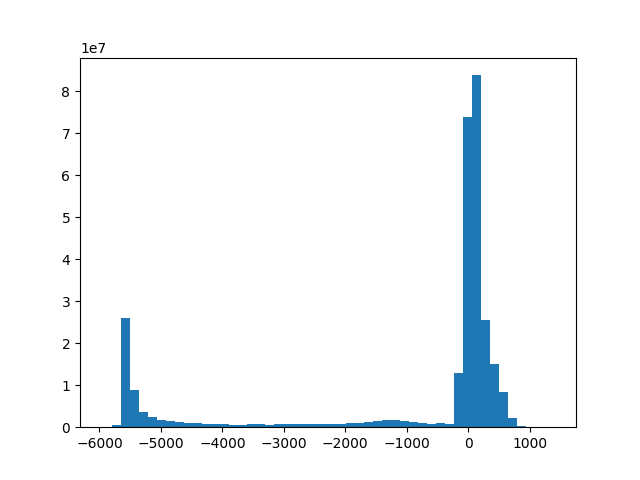

In [6]:
plt.figure()
plt.hist(np.where(np.isnan(elev.values.flatten()), -99999, elev.values.flatten()), bins=50)


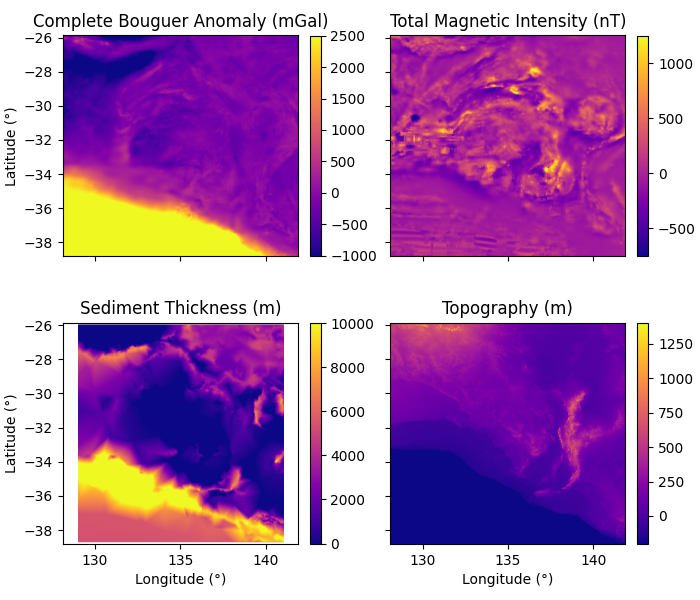

In [7]:
extent = [x.min(), x.max(), y.min(), y.max()]

fig, axes = plt.subplots(
    2, 2,
    figsize=(7, 6),
    constrained_layout=True,
    sharex=True,
    sharey=True
)
kw = dict(extent=extent, origin="upper")

# ---- Gravity ----
im0 = axes[0, 0].imshow(grav.values, cmap=cmap, **kw)
im0.set_clim(-1000, 2500)
#axes[0, 0].imshow(hs, cmap="gray", alpha=0.35, **kw)
axes[0, 0].set_title("Complete Bouguer Anomaly (mGal)")
plt.colorbar(im0, ax=axes[0, 0], shrink=0.8)

# ---- Magnetics ----
im1 = axes[0, 1].imshow(mag.values, cmap=cmap, **kw)
im1.set_clim(-750, 1250)
#axes[0, 1].imshow(hs, cmap="gray", alpha=0.35, **kw)
axes[0, 1].set_title("Total Magnetic Intensity (nT)")
plt.colorbar(im1, ax=axes[0, 1], shrink=0.8)

# ---- Sediment thickness ----
im2 = axes[1, 0].imshow(sed.interp_like(grav).values, cmap=cmap, **kw)
im2.set_clim(0, 10000)
#axes[1, 0].imshow(hs, cmap="gray", alpha=0.35, **kw)
axes[1, 0].set_title("Sediment Thickness (m)")
plt.colorbar(im2, ax=axes[1, 0], shrink=0.8)

# ---- Topography ----
im3 = axes[1, 1].imshow(elev.values, cmap=cmap, **kw)
im3.set_clim(-200, 1400)
#axes[1, 1].imshow(hs, cmap="gray", alpha=0.35, **kw)
axes[1, 1].set_title("Topography (m)")
plt.colorbar(im3, ax=axes[1, 1], shrink=0.8)

for ax in axes[1]:
    ax.set_xlabel("Longitude (°)")
for ax in axes[:, 0]:
    ax.set_ylabel("Latitude (°)")

plt.show()


## 2. Interactive Profile Selection

Click two points on the map to define a profile.
The profile will be extracted by interpolation.

This simulates how profiles are chosen in real interpretation workflows.


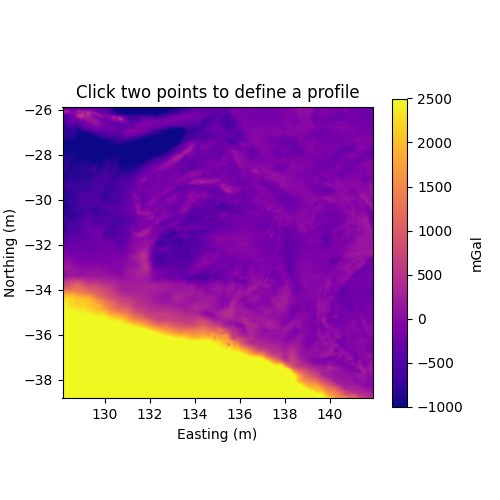

In [8]:
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(grav.values, cmap=cmap, extent=extent, origin="upper")
im.set_clim(-1000, 2500)
plt.colorbar(im, ax=ax, shrink=0.8, label="mGal")
ax.set_title("Click two points to define a profile")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")

points = []

def onclick(event):
    if event.inaxes:
        points.append((event.xdata, event.ydata))
        ax.plot(event.xdata, event.ydata, "ro", markersize=8)
        fig.canvas.draw()
        if len(points) == 2:
            fig.canvas.mpl_disconnect(cid)
            ax.plot(
                [points[0][0], points[1][0]],
                [points[0][1], points[1][1]],
                "r-", linewidth=1.5
            )
            fig.canvas.draw()
            print(f"Profile set: {points[0]}  →  {points[1]}")

cid = fig.canvas.mpl_connect("button_press_event", onclick)


Using fallback profile endpoints: [(132.0, -28.0), (134.0, -30.0)]


/Users/dhasterok/Documents/GitHub/EART_3017/.venv/lib/python3.14/site-packages/pyproj/geod.py:675: UserWarning: Back azimuth is being returned by default to be compatible with fwd()This is a breaking change for pyproj 3.5+.To avoid this warning, set return_back_azimuth=True.Otherwise, to restore old behaviour, set return_back_azimuth=False.This warning will be removed in future version.
  warnings.warn(


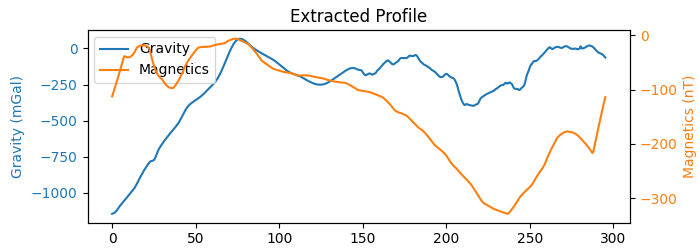

In [9]:
# Extract profile once two points are defined
# Falls back to hardcoded endpoints if none were clicked
if len(points) < 2:
    points = [(132.0, -28.0), (134.0, -30.0)]
    print("Using fallback profile endpoints:", points)

from pyproj import Geod

def extract_profile(da, p1, p2, n=500):
    """Interpolate a profile from an xarray DataArray along a great-circle path.

    p1, p2    : (lon, lat) tuples matching da.x / da.y (geographic, degrees)
    Returns   : (values, distance_m) — profile values and along-track distance in metres
    """
    arr = da.values.astype(float)   # (ny, nx)
    gx  = da.x.values.astype(float) # longitudes, must be increasing
    gy  = da.y.values.astype(float) # latitudes, may decrease

    # RegularGridInterpolator requires strictly increasing axes
    if gy[0] > gy[-1]:
        gy  = gy[::-1]
        arr = arr[::-1, :]

    interp = RegularGridInterpolator(
        (gy, gx), arr,
        method="linear",
        bounds_error=False,
        fill_value=np.nan
    )

    # Sample points along a geodesic (GRS80 ellipsoid — matches GDA2020)
    geod = Geod(ellps="GRS80")
    r = geod.inv_intermediate(
        p1[0], p1[1], p2[0], p2[1],
        npts=n - 2, initial_idx=0, terminus_idx=0
    )
    lons = np.array([p1[0]] + list(r.lons) + [p2[0]])
    lats = np.array([p1[1]] + list(r.lats) + [p2[1]])

    # Cumulative along-track distance in metres
    _, _, step_m = geod.inv(lons[:-1], lats[:-1], lons[1:], lats[1:])
    dist_m = np.concatenate([[0.0], np.cumsum(step_m)])

    values = interp(np.column_stack([lats, lons]))
    return values, dist_m

profile_grav, distance = extract_profile(grav, points[0], points[1])
profile_mag,  _        = extract_profile(mag,  points[0], points[1])

fig, ax1 = plt.subplots(figsize=(7, 2.5))
ax2 = ax1.twinx()

l1, = ax1.plot(distance / 1e3, profile_grav, color="tab:blue",   label="Gravity")
l2, = ax2.plot(distance / 1e3, profile_mag,  color="tab:orange",  label="Magnetics")

ax1.set_xlabel("Distance (km)")
ax1.set_ylabel("Gravity (mGal)",    color="tab:blue")
ax2.set_ylabel("Magnetics (nT)",     color="tab:orange")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:orange")
ax1.set_title("Extracted Profile")
ax1.legend(handles=[l1, l2], loc="upper left")
plt.show()


## 3. One-Dimensional Profile Continuation

Having extracted profiles from both the gravity and magnetic grids, we can now
examine how the fields change with altitude using **continuation**.

Continuation is performed entirely in the wavenumber domain.  For a profile
sampled at spacing $\Delta x$, the discrete wavenumbers are
$k = 0, \pm 1/N\Delta x, \ldots$  The continuation filter is:

$$H(k, z) = e^{-2\pi |k| z}$$

where $z$ is the **continuation height** (positive = upward, negative = downward).

**Upward continuation** ($z > 0$) exponentially damps high wavenumbers (short
wavelengths), acting as a low-pass filter.  This suppresses shallow sources and
reveals the long-wavelength regional field.

**Downward continuation** ($z < 0$) inverts the filter, *amplifying* high
wavenumbers.  In theory this sharpens our view of sources, but in practice noise
is amplified exponentially and the result quickly becomes unstable.  Use the
slider below to push into negative $z$ and observe the breakdown firsthand.

> **Note on units.**  The wavenumbers returned by `np.fft.fftfreq` are in
> *cycles per sample* by default.  Passing the physical sample spacing
> $\Delta x$ (km) via the `d` argument gives wavenumbers in cycles/km,
> so the continuation height $z$ is also in km.


In [ ]:
def continuation_1d(profile, dz_km, dx_km):
    """Apply upward/downward continuation to a 1-D profile.

    Parameters
    ----------
    profile : 1-D array
    dz_km   : continuation height in km (positive = up, negative = down)
    dx_km   : sample spacing in km
    """
    N = len(profile)
    k = np.fft.fftfreq(N, d=dx_km)   # cycles/km
    F = np.fft.fft(profile)
    H = np.exp(-2 * np.pi * np.abs(k) * dz_km)
    return np.real(np.fft.ifft(F * H))

# Sample spacing derived from the distance vector (km)
_dx_km = (distance[-1] - distance[0]) / (len(distance) - 1) / 1e3

def _plot_continuation(dz):
    grav_cont = continuation_1d(profile_grav, dz, _dx_km)
    mag_cont  = continuation_1d(profile_mag,  dz, _dx_km)
    grav_res  = profile_grav - grav_cont
    mag_res   = profile_mag  - mag_cont
    dist_km   = distance / 1e3
    direction = "Upward" if dz > 0 else ("Downward" if dz < 0 else "No")

    fig, axes = plt.subplots(3, 2, figsize=(12, 7), sharex=True)
    (ax_g, ax_m), (ax_gc, ax_mc), (ax_gr, ax_mr) = axes

    # ---- Observed ----
    ax_g.plot(dist_km, profile_grav, color="tab:blue")
    ax_g.set_ylabel("Gravity (mGal)")
    ax_g.set_title("Observed")

    ax_m.plot(dist_km, profile_mag, color="tab:orange")
    ax_m.set_ylabel("Magnetics (nT)")
    ax_m.set_title("Observed")

    # ---- Continued (regional) + observed for reference ----
    ax_gc.plot(dist_km, profile_grav, color="tab:blue",   lw=1,   alpha=0.4, label="Observed")
    ax_gc.plot(dist_km, grav_cont,    color="tab:red",    lw=1.5, linestyle="--", label="Regional")
    ax_gc.set_ylabel("Gravity (mGal)")
    ax_gc.set_title(f"{direction} continuation {abs(dz):.0f} km (regional)")
    ax_gc.legend(loc="upper right", fontsize=8)

    ax_mc.plot(dist_km, profile_mag, color="tab:orange", lw=1,   alpha=0.4, label="Observed")
    ax_mc.plot(dist_km, mag_cont,    color="tab:purple", lw=1.5, linestyle="--", label="Regional")
    ax_mc.set_ylabel("Magnetics (nT)")
    ax_mc.set_title(f"{direction} continuation {abs(dz):.0f} km (regional)")
    ax_mc.legend(loc="upper right", fontsize=8)

    # ---- Residual ----
    ax_gr.plot(dist_km, grav_res, color="tab:blue")
    ax_gr.axhline(0, color="k", lw=0.5, linestyle=":")
    ax_gr.set_ylabel("Gravity (mGal)")
    ax_gr.set_xlabel("Distance (km)")
    ax_gr.set_title("Residual (observed − regional)")

    ax_mr.plot(dist_km, mag_res, color="tab:orange")
    ax_mr.axhline(0, color="k", lw=0.5, linestyle=":")
    ax_mr.set_ylabel("Magnetics (nT)")
    ax_mr.set_xlabel("Distance (km)")
    ax_mr.set_title("Residual (observed − regional)")

    fig.suptitle(f"1-D Continuation — {direction.lower()} {abs(dz):.0f} km",
                 fontsize=11)
    plt.tight_layout()
    plt.show()

widgets.interact(
    _plot_continuation,
    dz=widgets.FloatSlider(
        value=5, min=-20, max=100, step=1,
        description="Dz (km)",
        continuous_update=False,
        style={"description_width": "initial"},
        layout=widgets.Layout(width="500px")
    )
);


interactive(children=(FloatSlider(value=5.0, continuous_update=False, description='Dz (km)', layout=Layout(wid…

### Interpretation Questions

1. **Upward continuation as a low-pass filter.**  As you increase the continuation
   height, which features disappear first — broad, regional anomalies or narrow,
   localised ones?  What does this tell you about the relationship between anomaly
   wavelength and source depth?

2. **Residual anomalies.**  What geological features might the residual profile
   (observed $-$ regional) represent?  Are the residuals in the gravity and
   magnetic profiles spatially correlated?  What could explain agreement or
   disagreement between them?

3. **Choosing a continuation height.**  There is no single "correct" continuation
   height for separating regional from residual.  What criteria might you use to
   make a defensible choice?  How sensitive is your interpretation to that choice?

4. **Instability of downward continuation.**  Move the slider into negative values.
   At approximately what depth does the downward-continued field become visibly
   unstable?  Does instability set in at the same depth for gravity and magnetics,
   or does one break down sooner?  Why might they differ?

5. **Physical meaning of the continued field.**  Upward continuation produces the
   field that *would* be observed at a higher elevation.  Does the continued
   profile look like what you would expect from a smoother, more distant source
   distribution?  Are there any features that seem physically unreasonable?


## 4. Two-Dimensional Gravity Continuation

Moving from profiles to grids, the continuation filter generalises to two spatial
frequencies $(k_x, k_y)$:

$$H(k_x, k_y, z) = e^{-2\pi \sqrt{k_x^2 + k_y^2}\, z}$$

where $z > 0$ is upward and $z < 0$ is downward continuation.  The radial
wavenumber $|\mathbf{k}| = \sqrt{k_x^2 + k_y^2}$ makes the filter **isotropic** — it
attenuates equally in all horizontal directions.

**Upward continuation** smooths the observed field by suppressing short-wavelength
anomalies from shallow sources, isolating the long-wavelength **regional** field.
The **residual** (observed $-$ regional) then highlights shallower or more local
sources.

> **Grid spacing.**  The gravity grid is stored in geographic coordinates (degrees).
> Wavenumbers must be in physical units, so we convert degrees to kilometres using
> the mean latitude of the study area before calling `np.fft.fftfreq`.


In [ ]:
def continuation_2d(grid, dx_km, dy_km, dz_km):
    """2-D upward/downward continuation.

    Parameters
    ----------
    grid   : 2-D float array
    dx_km  : column (E-W) spacing in km
    dy_km  : row (N-S) spacing in km
    dz_km  : continuation height in km  (positive = up, negative = down)
    """
    ny, nx = grid.shape
    kx = np.fft.fftfreq(nx, d=dx_km)
    ky = np.fft.fftfreq(ny, d=dy_km)
    KX, KY = np.meshgrid(kx, ky)
    K  = np.sqrt(KX**2 + KY**2)
    H  = np.exp(-2 * np.pi * K * dz_km)
    return np.real(np.fft.ifft2(np.fft.fft2(grid) * H))

# Physical grid spacing: convert degrees → km at mean latitude
_lat0       = (y.min() + y.max()) / 2
_grav_dx_km = dx * 111.32 * np.cos(np.radians(_lat0))
_grav_dy_km = dy * 111.0

def _plot_grav_2d_cont(dz):
    grav_reg = continuation_2d(grav.values, _grav_dx_km, _grav_dy_km, dz)
    grav_res = grav.values - grav_reg
    direction = "Upward" if dz > 0 else ("Downward" if dz < 0 else "No")

    vobs = np.nanpercentile(np.abs(grav.values), 98)
    vreg = np.nanpercentile(np.abs(grav_reg),    98)
    vres = np.nanpercentile(np.abs(grav_res),    98)

    fig, axes = plt.subplots(1, 3, figsize=(7, 2.5), sharex=True, sharey=True,
                             constrained_layout=True)
    kw = dict(extent=extent, origin="upper", cmap=cmap)

    im0 = axes[0].imshow(grav.values, **kw); im0.set_clim(-vobs, vobs)
    axes[0].set_title("Observed (mGal)")
    plt.colorbar(im0, ax=axes[0], shrink=0.75)

    im1 = axes[1].imshow(grav_reg, **kw); im1.set_clim(-vreg, vreg)
    axes[1].set_title(f"Regional — {direction.lower()} {abs(dz):.0f} km (mGal)")
    plt.colorbar(im1, ax=axes[1], shrink=0.75)

    im2 = axes[2].imshow(grav_res, **kw); im2.set_clim(-vres, vres)
    axes[2].set_title("Residual (mGal)")
    plt.colorbar(im2, ax=axes[2], shrink=0.75)

    for ax in axes:
        ax.set_xlabel("Longitude (°)")
    axes[0].set_ylabel("Latitude (°)")
    fig.suptitle(f"Gravity continuation — {direction.lower()} {abs(dz):.0f} km", fontsize=11)
    plt.show()

widgets.interact(
    _plot_grav_2d_cont,
    dz=widgets.FloatSlider(
        value=25, min=5, max=100, step=5,
        description="\u0394z (km)",
        continuous_update=False,
        style={"description_width": "initial"},
        layout=widgets.Layout(width="500px")
    )
);


interactive(children=(FloatSlider(value=25.0, continuous_update=False, description='Δz (km)', layout=Layout(wi…

### 4b. Isostatic Correction and Comparison with Spectral Continuation

Spectral continuation is a purely mathematical way to define a regional field — it
knows nothing about geology.  An alternative is to compute a **physically motivated
regional** from isostatic theory.

Under the **Airy isostasy** model, surface topography is compensated by a crustal
root that floats on the denser mantle.  For a topographic load of height $h$
(positive upward, in metres), the root thickness is:

$$t_r = \frac{\rho_c}{\rho_m - \rho_c}\, h$$

The gravitational effect of that root, approximated as an infinite slab, is:

$$g_\mathrm{iso}(x,y) = 2\pi G\,(\rho_m - \rho_c)\, t_r(x,y) = 2\pi G\,\rho_c\, h(x,y)$$

Subtracting this from the observed gravity gives the **isostatic residual**, which
reflects anomalies *not* explained by simple Airy compensation of topography —
for example, dense intrusions, uncompensated loads, or lateral density variations
in the crust.

> **Note.**  Only positive topography (above sea level) drives an Airy root in
> this simple model; ocean bathymetry and sub-sea-level topography are set to
> zero.

The maps below use a **fixed reference continuation height** of 25 km for the
spectral regional so you can make a direct side-by-side comparison.  Use the
interactive widget above to explore other heights.


In [ ]:
# ── Isostatic correction ─────────────────────────────────────────────────────
G_SI  = 6.67430e-11   # m^3 kg^-1 s^-2
rho_c = 2800.0        # crust  kg/m^3
rho_m = 3300.0        # mantle kg/m^3

# Resample elevation onto the gravity grid for isostatic computation
topo_on_grav = elev.interp(
    x=xr.DataArray(x, dims="x"),
    y=xr.DataArray(y, dims="y"),
    method="linear"
).values  # (ny, nx), metres

# Only positive elevations drive an Airy root
h = np.where(topo_on_grav > 0, topo_on_grav.astype(float), 0.0)   # m

root_thick = (rho_c / (rho_m - rho_c)) * h        # m
g_iso      = 2 * np.pi * G_SI * (rho_m - rho_c) * root_thick  # m/s^2
g_iso_mgal = g_iso * 1e5                           # mGal

grav_iso_res = grav.values - g_iso_mgal

# ── Spectral regional at reference height ────────────────────────────────────
_z_ref       = 25.0   # km
grav_reg_ref = continuation_2d(grav.values, _grav_dx_km, _grav_dy_km, _z_ref)
grav_res_ref = grav.values - grav_reg_ref

print(f"Isostatic correction  — range: {g_iso_mgal.min():.1f} to {g_iso_mgal.max():.1f} mGal")
print(f"Spectral regional     — range: {grav_reg_ref.min():.1f} to {grav_reg_ref.max():.1f} mGal  (z = {_z_ref} km)")

Isostatic correction  — range: 0.0 to 162.3 mGal
Spectral regional     — range: -941.8 to 3148.6 mGal  (z = 25.0 km)


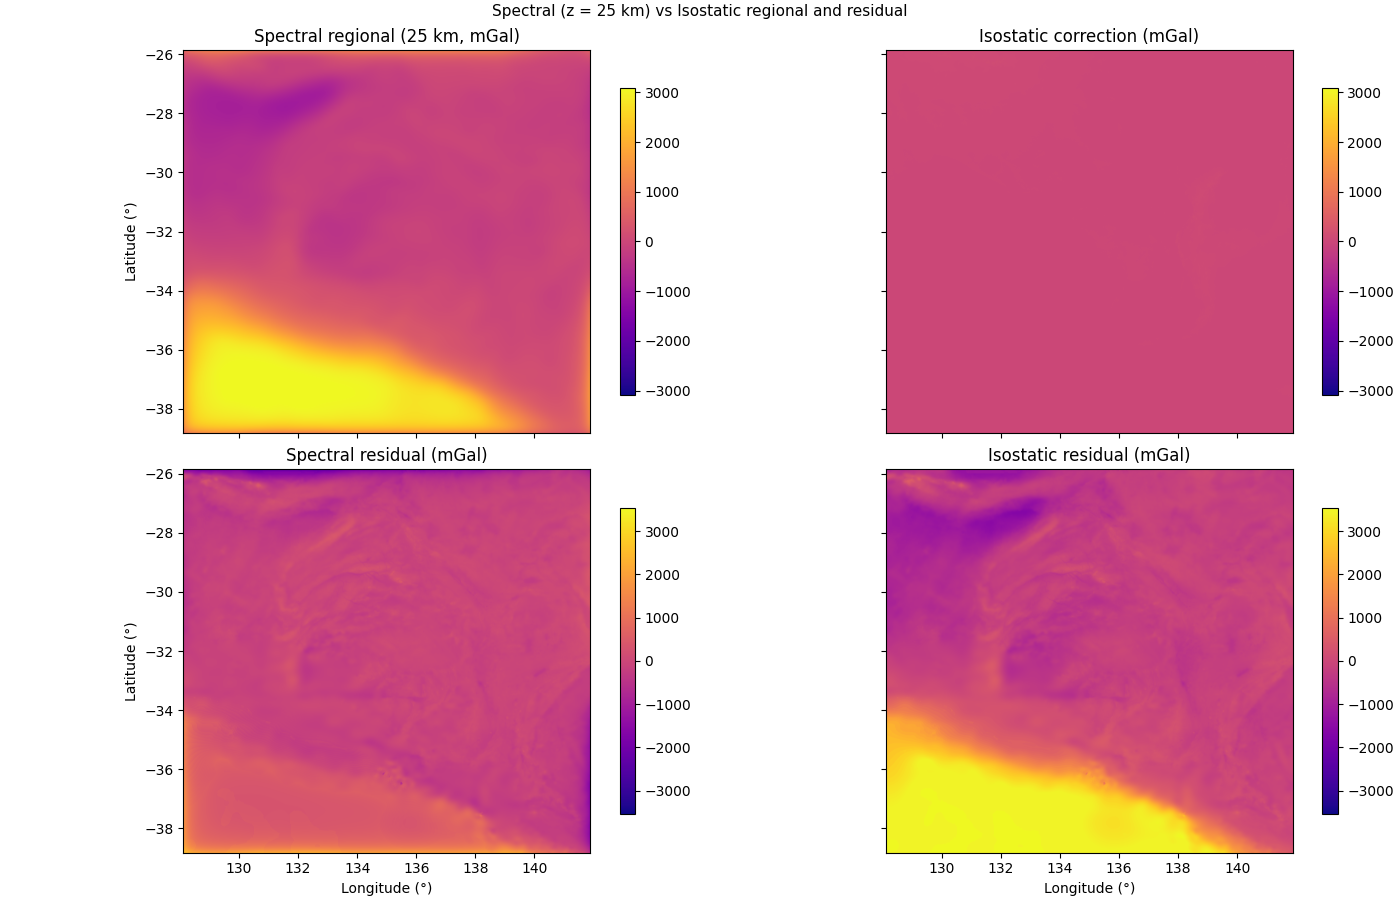

In [ ]:
# ── Comparison: spectral vs isostatic ────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(7, 4.5), sharex=True, sharey=True,
                         constrained_layout=True)
kw = dict(extent=extent, origin="upper", cmap=cmap)

# Row 0: regional fields
vr = max(np.nanpercentile(np.abs(grav_reg_ref), 98),
         np.nanpercentile(np.abs(g_iso_mgal),   98))
im00 = axes[0, 0].imshow(grav_reg_ref, **kw); im00.set_clim(-vr, vr)
axes[0, 0].set_title(f"Spectral regional ({_z_ref:.0f} km, mGal)")
plt.colorbar(im00, ax=axes[0, 0], shrink=0.8)

im01 = axes[0, 1].imshow(g_iso_mgal, **kw); im01.set_clim(-vr, vr)
axes[0, 1].set_title("Isostatic correction (mGal)")
plt.colorbar(im01, ax=axes[0, 1], shrink=0.8)

# Row 1: residual fields
vres = max(np.nanpercentile(np.abs(grav_res_ref),  98),
           np.nanpercentile(np.abs(grav_iso_res),  98))
im10 = axes[1, 0].imshow(grav_res_ref, **kw); im10.set_clim(-vres, vres)
axes[1, 0].set_title("Spectral residual (mGal)")
plt.colorbar(im10, ax=axes[1, 0], shrink=0.8)

im11 = axes[1, 1].imshow(grav_iso_res, **kw); im11.set_clim(-vres, vres)
axes[1, 1].set_title("Isostatic residual (mGal)")
plt.colorbar(im11, ax=axes[1, 1], shrink=0.8)

for ax in axes[1]:
    ax.set_xlabel("Longitude (°)")
for ax in axes[:, 0]:
    ax.set_ylabel("Latitude (°)")

fig.suptitle(f"Spectral (z = {_z_ref:.0f} km) vs Isostatic regional and residual", fontsize=11)
plt.show()


### Interpretation Questions

1. How well do the spectral regional and isostatic correction agree spatially?
   Which areas show the largest differences, and why?
2. How does the spectral residual change as you increase the continuation height
   in the interactive plot above?  At what height does it begin to resemble the
   isostatic residual?
3. What geological features might explain anomalies present in the spectral
   residual but absent (or reduced) in the isostatic residual?
4. What assumptions in the Airy isostasy model most strongly limit its accuracy
   here?


## 5. Reduction to the Pole

Magnetic anomalies measured as the total-field intensity (TMI) are asymmetric
because the Earth's field — and the induced magnetisation — are inclined.  A
positive anomaly lies slightly to the south of the causative body in the Southern
Hemisphere.

**Reduction to the pole (RTP)** applies a phase correction in the wavenumber
domain that transforms the data as though both the field and magnetisation were
vertical (as they would be at the geomagnetic pole).  This centres anomalies
over their sources, making structural interpretation more straightforward.

The RTP filter is:

$$H_\mathrm{RTP}(k_x, k_y) = \frac{1}{\Theta(k_x, k_y)^2}$$

where the direction-cosine factor is

$$\Theta = \sin I + i\cos I \left( \frac{k_x \cos D + k_y \sin D}{|\mathbf{k}|} \right)$$

and $I$ is the geomagnetic inclination and $D$ is the declination.

Because $\Theta \to 0$ near the equator (where $I \approx 0$), the filter becomes
unstable at low latitudes.  South Australia sits at mid-latitudes
($I \approx -60°$), so RTP is reasonably stable here but can still amplify
noise at high wavenumbers.  A small **water-level** parameter $\varepsilon$
is added to the denominator to stabilise the inversion.


In [ ]:
def reduce_to_pole(grid, dx_km, dy_km, incl_deg, decl_deg, eps=0.05):
    """Reduce a total-field magnetic grid to the pole.

    Parameters
    ----------
    grid     : 2-D float array
    dx_km    : column (E-W) spacing in km
    dy_km    : row (N-S) spacing in km
    incl_deg : geomagnetic inclination (degrees, negative in Southern Hemisphere)
    decl_deg : geomagnetic declination (degrees, positive east)
    eps      : water-level stabilisation factor
    """
    I = np.radians(incl_deg)
    D = np.radians(decl_deg)

    ny, nx = grid.shape
    kx = np.fft.fftfreq(nx, d=dx_km)
    ky = np.fft.fftfreq(ny, d=dy_km)
    KX, KY = np.meshgrid(kx, ky)
    K = np.sqrt(KX**2 + KY**2)
    K[K == 0] = 1e-10   # avoid DC singularity

    # Direction-cosine factor \Theta (Blakely 1995, eq. 12.4)
    phase = (np.sin(I) * K
             + 1j * np.cos(I) * (KX * np.cos(D) + KY * np.sin(D))) / K

    # Stabilised inverse: 1/phase^2  with water-level eps
    H_rtp = np.conj(phase)**2 / (np.abs(phase)**2 + eps)**2

    F = np.fft.fft2(grid)
    return np.real(np.fft.ifft2(F * H_rtp))

# Physical spacing for the magnetic grid
_mag_lat0   = (mag.y.values.min() + mag.y.values.max()) / 2
_mag_dx_km  = (mag.x.values[1] - mag.x.values[0]) * 111.32 * np.cos(np.radians(_mag_lat0))
_mag_dy_km  = abs(mag.y.values[1] - mag.y.values[0]) * 111.0

def _plot_rtp(I, D):
    mag_rtp  = reduce_to_pole(mag.values, _mag_dx_km, _mag_dy_km, I, D)
    mag_diff = mag_rtp - mag.values

    vt = np.nanpercentile(np.abs(mag.values), 98)
    vd = np.nanpercentile(np.abs(mag_diff),   98)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True,
                             constrained_layout=True)
    kw = dict(extent=extent, origin="upper", cmap=cmap)

    im0 = axes[0].imshow(mag.values, **kw); im0.set_clim(-vt, vt)
    axes[0].set_title("TMI (nT)")
    plt.colorbar(im0, ax=axes[0], shrink=0.75)

    im1 = axes[1].imshow(mag_rtp, **kw); im1.set_clim(-vt, vt)
    axes[1].set_title(f"RTP  (I = {I}°, D = {D}°)  (nT)")
    plt.colorbar(im1, ax=axes[1], shrink=0.75)

    im2 = axes[2].imshow(mag_diff, **kw); im2.set_clim(-vd, vd)
    axes[2].set_title("Difference: RTP \u2212 TMI (nT)")
    plt.colorbar(im2, ax=axes[2], shrink=0.75)

    for ax in axes:
        ax.set_xlabel("Longitude (°)")
    axes[0].set_ylabel("Latitude (°)")
    plt.show()

widgets.interact(
    _plot_rtp,
    I=widgets.IntSlider(value=-60, min=-90, max=-10, step=5,
                        description="I (°)", style={"description_width": "initial"},
                        layout=widgets.Layout(width="400px")),
    D=widgets.IntSlider(value=0,   min=-30, max=30,  step=2,
                        description="D (°)", style={"description_width": "initial"},
                        layout=widgets.Layout(width="400px")),
);


### Interpretation Questions

1. How does RTP change the positions of the major anomalies relative to the
   original TMI?  Are they shifted northward or southward, and by roughly how much?
2. Experiment with the inclination slider.  At what inclination do artefacts
   (ringing, extreme amplitudes) begin to appear?  What does this tell you about
   applying RTP near the equator?
3. How does the difference map (RTP $-$ TMI) relate to the asymmetry of individual
   anomalies?  What geological information might be encoded in that difference?
4. The RTP filter assumes purely **induced** magnetisation (parallel to the
   ambient field).  How would **remanent** magnetisation with a different direction
   affect the result?


## 6. Sediment-Thickness Correction for RTP [*Optional*]

Sedimentary rocks are essentially non-magnetic.  Where a thick sedimentary basin
covers crystalline basement, the magnetic signal originates from deeper sources,
and the short-wavelength content of that signal is attenuated by propagating
through the extra distance.  In the wavenumber domain, the attenuation from a
layer of thickness $z_s$ is:

$$A(|\mathbf{k}|, z_s) = e^{-2\pi |\mathbf{k}|\, z_s}$$

To partially **undo** this attenuation — effectively moving the observation level
down to the top of the magnetic basement — we multiply the spectrum by the inverse:

$$C(|\mathbf{k}|, z_s) = e^{+2\pi |\mathbf{k}|\, z_s}$$

This is identical to **downward continuation** by $z_s$, and inherits the same
instability: high wavenumbers are amplified exponentially.  A **Gaussian taper**
is therefore applied to suppress the noise blow-up:

$$H_\mathrm{sed}(|\mathbf{k}|) = e^{+2\pi |\mathbf{k}|\, z_s}
\cdot e^{-2\pi^2 |\mathbf{k}|^2 \lambda^2}$$

where $\lambda$ is a damping length scale (km).

Because sediment thickness varies spatially, a truly rigorous correction would
require a spatially variable filter — computationally demanding and beyond the
scope of this exercise.  Here we use the **mean sediment thickness** of the study
area as a single, uniform correction.  The slider lets you explore the sensitivity
to $z_s$, and a separate map shows where the spatial variation is largest so you
can judge where the uniform approximation is weakest.

> **Caveat.**  This is an experimental approach.  The results should be treated as
> qualitative.  Improvements would require either a tiled/windowed spectral method
> or iterative inversion.


In [ ]:
# Resample sediment onto the magnetic grid
sed_on_mag = sed.interp_like(mag, method="linear").fillna(0.0).values  # metres

# Convert to km and compute summary statistics
sed_on_mag_km = sed_on_mag / 1e3
print(f"Sediment thickness on mag grid: "
      f"min = {sed_on_mag_km.min():.2f} km, "
      f"mean = {np.nanmean(sed_on_mag_km):.2f} km, "
      f"max = {sed_on_mag_km.max():.2f} km")

def rtp_with_sed_correction(grid, dx_km, dy_km, incl_deg, decl_deg,
                             z_sed_km, damp_km=15.0, eps=0.05):
    """RTP with a uniform sediment-depth correction and Gaussian damping.

    The filter applied is H_rtp * exp(+2*pi*K*z_sed) * Gaussian(K, damp_km).
    """
    I = np.radians(incl_deg)
    D = np.radians(decl_deg)

    ny, nx = grid.shape
    kx = np.fft.fftfreq(nx, d=dx_km)
    ky = np.fft.fftfreq(ny, d=dy_km)
    KX, KY = np.meshgrid(kx, ky)
    K = np.sqrt(KX**2 + KY**2)
    K[K == 0] = 1e-10

    # RTP filter
    phase = (np.sin(I) * K
             + 1j * np.cos(I) * (KX * np.cos(D) + KY * np.sin(D))) / K
    H_rtp = np.conj(phase)**2 / (np.abs(phase)**2 + eps)**2

    # Sediment correction: amplify attenuated basement signals, Gaussian-damped
    H_sed = np.exp(2 * np.pi * K * z_sed_km) * np.exp(-2 * np.pi**2 * K**2 * damp_km**2)

    F = np.fft.fft2(grid)
    return np.real(np.fft.ifft2(F * H_rtp * H_sed))

def _plot_sed_rtp(I, D, z_sed, damp):
    mag_rtp      = reduce_to_pole(mag.values, _mag_dx_km, _mag_dy_km, I, D)
    mag_sed_rtp  = rtp_with_sed_correction(mag.values, _mag_dx_km, _mag_dy_km,
                                           I, D, z_sed, damp_km=damp)
    diff = mag_sed_rtp - mag_rtp

    vt = np.nanpercentile(np.abs(mag_rtp),     98)
    vd = np.nanpercentile(np.abs(diff),         98)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True,
                             constrained_layout=True)
    kw = dict(extent=extent, origin="upper", cmap=cmap)

    im0 = axes[0].imshow(mag_rtp, **kw); im0.set_clim(-vt, vt)
    axes[0].set_title(f"Standard RTP  (I={I}°, D={D}°)  (nT)")
    plt.colorbar(im0, ax=axes[0], shrink=0.75)

    im1 = axes[1].imshow(mag_sed_rtp, **kw); im1.set_clim(-vt, vt)
    axes[1].set_title(f"Sed-corrected RTP  (z = {z_sed:.1f} km)  (nT)")
    plt.colorbar(im1, ax=axes[1], shrink=0.75)

    im2 = axes[2].imshow(diff, **kw); im2.set_clim(-vd, vd)
    axes[2].set_title("Difference: sed-corrected \u2212 standard (nT)")
    plt.colorbar(im2, ax=axes[2], shrink=0.75)

    for ax in axes:
        ax.set_xlabel("Longitude (°)")
    axes[0].set_ylabel("Latitude (°)")
    plt.show()

widgets.interact(
    _plot_sed_rtp,
    I    =widgets.IntSlider(  value=-60, min=-90, max=-10, step=5,
                              description="I (°)",   style={"description_width":"initial"},
                              layout=widgets.Layout(width="420px")),
    D    =widgets.IntSlider(  value=0,   min=-30, max=30,  step=2,
                              description="D (°)",   style={"description_width":"initial"},
                              layout=widgets.Layout(width="420px")),
    z_sed=widgets.FloatSlider(value=np.nanmean(sed_on_mag_km), min=0.0, max=5.0, step=0.1,
                              description="z_sed (km)", style={"description_width":"initial"},
                              layout=widgets.Layout(width="420px"),
                              continuous_update=False),
    damp =widgets.FloatSlider(value=15.0, min=2.0, max=50.0, step=1.0,
                              description="\u03bb damp (km)", style={"description_width":"initial"},
                              layout=widgets.Layout(width="420px"),
                              continuous_update=False),
);


### Interpretation Questions

1. Where does the sediment correction make the largest difference to the RTP result?
   Does this correspond to the areas of thickest sediment?
2. What happens when you increase the damping length $\lambda$?  What signal is
   being suppressed, and is this geologically sensible?
3. The correction is applied uniformly using the mean sediment thickness.  In which
   parts of the study area do you expect this approximation to be most and least
   valid?
4. Could a similar approach be applied to the **gravity** field to account for the
   sediment load?  How would it differ from the isostatic correction computed in
   Section 4?
5. What additional information or data would you need to make this correction
   spatially variable in a rigorous way?


## 7. Synthesis

Answer the following questions drawing on all sections of this notebook.

1. **Wavelength and depth.**  How do Fourier-domain methods relate signal wavelength
   to source depth?  What is the approximate relationship, and what are its
   limitations?

2. **Defining a regional field.**  What are the advantages and disadvantages of
   using spectral continuation versus isostatic correction to separate regional
   from residual gravity?

3. **Instability of downward continuation.**  Why is downward continuation unstable
   in practice?  What strategies can mitigate this, and what information is lost?

4. **Role of sediment thickness.**  In what ways does sediment thickness affect
   the interpretation of both gravity and magnetic data?  Does knowing the sediment
   thickness fully resolve the interpretation problem?

5. **Non-uniqueness.**  All potential-field methods suffer from the fundamental
   non-uniqueness of the inverse problem.  Give one concrete example from this
   notebook where two different assumptions produced similar-looking results.
   What additional data or constraints could help discriminate between them?
